# Prepare environment

In [10]:
LOCAL = True

In [2]:
if not LOCAL:
    import sys
    sys.path.insert(1, '/kaggle/input/datasets/dominikaboguszewska/sigk-project-3-v3')

In [3]:
if not LOCAL:
    !pip install flip-evaluator
    !pip install lpips

  Using cached flip_evaluator-1.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.9 kB)
Using cached flip_evaluator-1.7-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (415 kB)
  Using cached lpips-0.1.4-py3-none-any.whl.metadata (10 kB)
Using cached lpips-0.1.4-py3-none-any.whl (53 kB)


In [11]:
import json
import random
import datetime

import numpy as np
import matplotlib.pyplot as plt
import flip_evaluator as flip

from tqdm import tqdm
from PIL import Image
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn

from phong_dataset import PhongDataset
from unet import UNet
from ddpm import DDPM
from evaluate import compute_metrics

In [12]:
if LOCAL:
    from config import DATA_DIR, DIFFUSION_MODEL_RESULTS, IMAGES_DIR
else:
    DATA_DIR = Path("/kaggle/input/datasets/dominikaboguszewska/sigk-project-3-v3/data/data")
    IMAGES_DIR = DATA_DIR / "images"
    DIFFUSION_MODEL_RESULTS = Path("/kaggle/working/diffusion_model_results")

In [6]:
DIFFUSION_MODEL_RESULTS.mkdir(parents=True, exist_ok=True)

In [13]:
FULL_DATASET_SIZE = 3000
TESTING_DATASET_SIZE = 600
VALIDATION_DATASET_SIZE = int((FULL_DATASET_SIZE - TESTING_DATASET_SIZE) * 0.15)
TRAINING_DATASET_SIZE = FULL_DATASET_SIZE - VALIDATION_DATASET_SIZE - TESTING_DATASET_SIZE

PARAMS_DIM = 10
IMAGE_SIZE = 128

BATCH_SIZE = 32

UNET_BASE_CHANNELS_NUM = 128
DIFFUSION_STEPS_NUM = 1000

EPOCHS = 200
LEARNING_RATE = 1e-4
VAL_METRIC_SAMPLES = 32
EARLY_STOPPING_PATIENCE = 10

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [15]:
def get_timestamp() -> str:
    ct = datetime.datetime.now()

    return ct.strftime("%Y-%m-%d_%H-%M-%S")

In [10]:
CURRENT_TIMESTAMP = get_timestamp()

CURRENT_RUN_DIRECTORY = Path(f"{DIFFUSION_MODEL_RESULTS}/{CURRENT_TIMESTAMP}")
CURRENT_RUN_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [11]:
print(CURRENT_TIMESTAMP)
print(CURRENT_RUN_DIRECTORY)

2026-04-27_21-00-49
/kaggle/working/diffusion_model_results/2026-04-27_21-00-49


# Load dataset

In [16]:
train_ids = list(range(0, TRAINING_DATASET_SIZE))
val_ids = list(range(TRAINING_DATASET_SIZE, FULL_DATASET_SIZE - TESTING_DATASET_SIZE))
test_ids = list(range(FULL_DATASET_SIZE - TESTING_DATASET_SIZE, FULL_DATASET_SIZE))

print(f"Training dataset size: {len(train_ids)}")
print(f"Validation dataset size: {len(val_ids)}")
print(f"Testing dataset size: {len(test_ids)}")

Training dataset size: 2040
Validation dataset size: 360
Testing dataset size: 600


In [17]:
print(f"Training dataset range: {min(train_ids)} - {max(train_ids)}")
print(f"Validation dataset range: {min(val_ids)} - {max(val_ids)}")
print(f"Testing dataset range: {min(test_ids)} - {max(test_ids)}")

Training dataset range: 0 - 2039
Validation dataset range: 2040 - 2399
Testing dataset range: 2400 - 2999


In [18]:
train_dataset = PhongDataset(DATA_DIR, train_ids)
val_dataset = PhongDataset(DATA_DIR, val_ids)
test_dataset = PhongDataset(DATA_DIR, test_ids)

In [19]:
print(f"Sample training data shape: {train_dataset[0][0].shape} (params), {train_dataset[0][1].shape} (image)")
print(f"Sample validation data shape: {val_dataset[0][0].shape} (params), {val_dataset[0][1].shape} (image)")
print(f"Sample testing data shape: {test_dataset[0][0].shape} (params), {test_dataset[0][1].shape} (image)")

Sample training data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)
Sample validation data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)
Sample testing data shape: torch.Size([10]) (params), torch.Size([3, 128, 128]) (image)


In [20]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [21]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 64
Number of validation batches: 12
Number of testing batches: 19


# Load model

In [18]:
model = UNet(param_dim=PARAMS_DIM, base_ch=UNET_BASE_CHANNELS_NUM).to(device)
ddpm = DDPM(T=DIFFUSION_STEPS_NUM, device=device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params}")

Model parameters: 22135427


# Training

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.999))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1
)

In [20]:
history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_lpips": [],
    "val_lpips": [],
    "train_ssim": [],
    "val_ssim": [],
    "train_hausdorff": [],
    "val_hausdorff": [],
    "lr": [],
}

best_val_loss = float("inf")
early_stopping_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for params, images in tqdm(train_loader, desc=f"Epoch {epoch+1} / {EPOCHS}", leave=False):
        params, images = params.to(device), images.to(device)

        t = torch.randint(0, ddpm.T, (images.size(0),), device=device)

        noisy, noise = ddpm.q_sample(images, t)

        pred = model(noisy, t, params)
        loss = F.mse_loss(pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        ema_model.update_parameters(model)
        scheduler.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for params, images in tqdm(val_loader, desc=f"Val loss {epoch+1} / {EPOCHS}", leave=False):
            params, images = params.to(device), images.to(device)

            t = torch.randint(0, ddpm.T, (images.size(0),), device=device)

            noisy, noise = ddpm.q_sample(images, t)

            pred = model(noisy, t, params)
            val_loss += F.mse_loss(pred, noise).item()

    val_loss /= len(val_loader)

    train_metrics = compute_metrics(ema_model, ddpm, train_loader, device, num_samples=VAL_METRIC_SAMPLES)
    val_metrics = compute_metrics(ema_model, ddpm, val_loader, device, num_samples=VAL_METRIC_SAMPLES)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ssim"].append(train_metrics["SSIM"])
    history["train_lpips"].append(train_metrics["LPIPS"])
    history["train_hausdorff"].append(train_metrics["Hausdorff"])
    history["val_ssim"].append(val_metrics["SSIM"])
    history["val_lpips"].append(val_metrics["LPIPS"])
    history["val_hausdorff"].append(val_metrics["Hausdorff"])
    history["lr"].append(scheduler.get_last_lr()[0])

    print(
        f"Epoch {epoch+1} / {EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train SSIM: {train_metrics['SSIM']:.4f} | Val SSIM: {val_metrics['SSIM']:.4f} | "
        f"Train LPIPS: {train_metrics['LPIPS']:.4f} | Val LPIPS: {val_metrics['LPIPS']:.4f} | "
        f"Train Hausdorff: {train_metrics['Hausdorff']:.2f} | Val Hausdorff: {val_metrics['Hausdorff']:.2f} | "
        f"lr: {scheduler.get_last_lr()[0]:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0

        torch.save(ema_model.state_dict(), CURRENT_RUN_DIRECTORY / "best_model.pth")
        print("Best model saved.")
    else:
        early_stopping_counter += 1
        print(f"No improvement for {early_stopping_counter} / {EARLY_STOPPING_PATIENCE} epochs.")

        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

print(f"Training finished with best val loss: {best_val_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 207MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


...

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Epoch 66 / 200 | Train Loss: 0.0025 | Val Loss: 0.0025 | Train SSIM: 0.0013 | Val SSIM: 0.0011 | Train LPIPS: 0.8854 | Val LPIPS: 0.8842 | Train Hausdorff: 75.61 | Val Hausdorff: 86.01 | lr: 0.000085
No improvement for 9 / 10 epochs.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


Epoch 67 / 200 | Train Loss: 0.0018 | Val Loss: 0.0010 | Train SSIM: 0.0012 | Val SSIM: 0.0012 | Train LPIPS: 0.8737 | Val LPIPS: 0.8651 | Train Hausdorff: 91.91 | Val Hausdorff: 77.83 | lr: 0.000084
No improvement for 10 / 10 epochs.
Early stopping triggered at epoch 67.
Training finished with best val loss: 0.0010


In [21]:
history_path = Path(f"{CURRENT_RUN_DIRECTORY}/history.json")

with open(history_path, "w") as f:
    json.dump(history, f, indent=4, sort_keys=True)

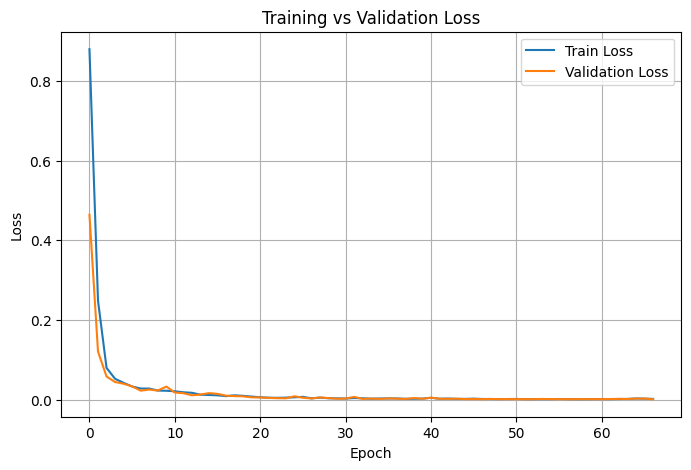

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/loss.png", dpi=300, bbox_inches="tight")

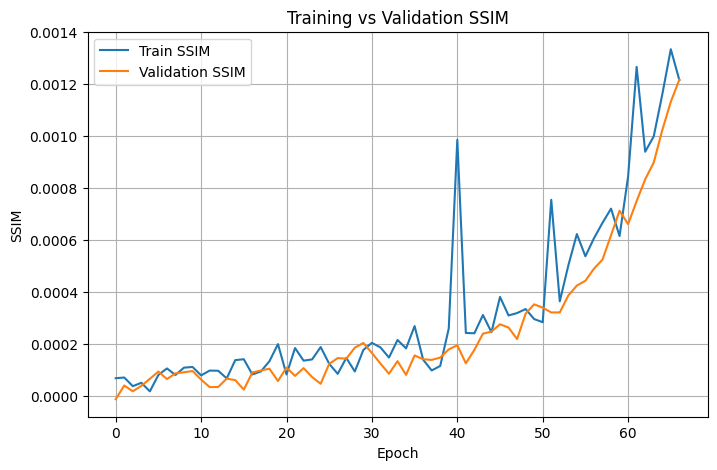

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_ssim"], label="Train SSIM")
plt.plot(history["val_ssim"], label="Validation SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.title("Training vs Validation SSIM")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/ssim.png", dpi=300, bbox_inches="tight")

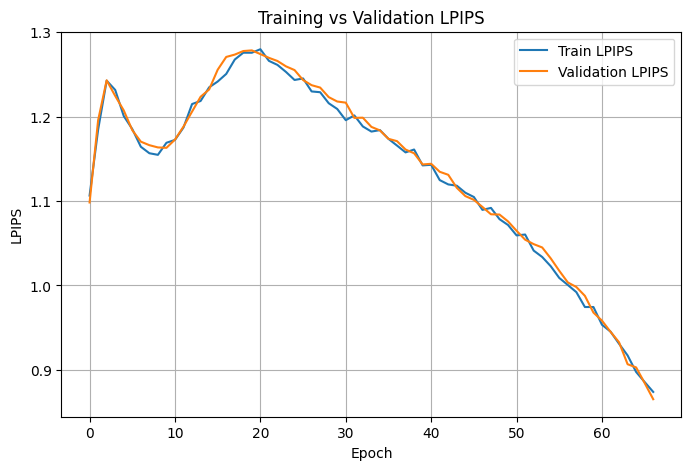

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_lpips"], label="Train LPIPS")
plt.plot(history["val_lpips"], label="Validation LPIPS")
plt.xlabel("Epoch")
plt.ylabel("LPIPS")
plt.title("Training vs Validation LPIPS")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/lpips.png", dpi=300, bbox_inches="tight")

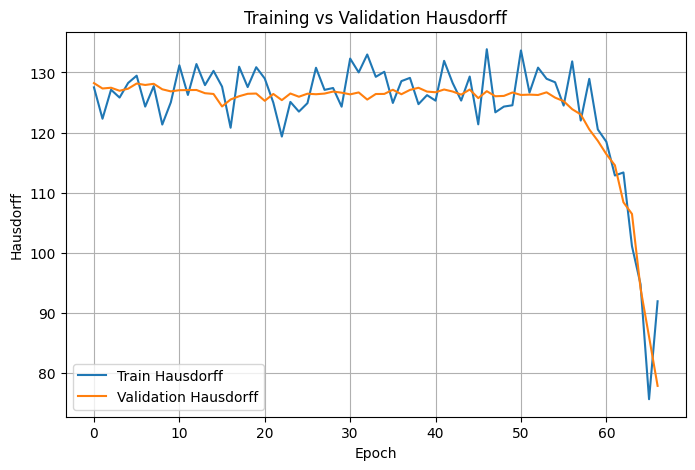

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_hausdorff"], label="Train Hausdorff")
plt.plot(history["val_hausdorff"], label="Validation Hausdorff")
plt.xlabel("Epoch")
plt.ylabel("Hausdorff")
plt.title("Training vs Validation Hausdorff")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/hausdorff.png", dpi=300, bbox_inches="tight")

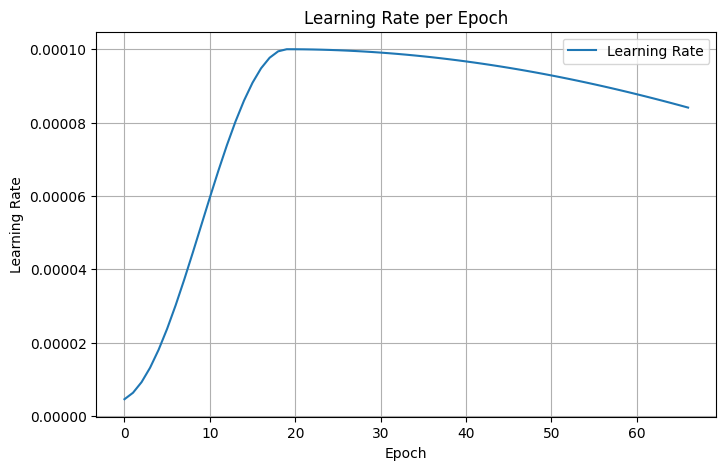

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history["lr"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate per Epoch")
plt.legend()
plt.grid(True)
plt.savefig(f"{CURRENT_RUN_DIRECTORY}/lr.png", dpi=300, bbox_inches="tight")

# Evaluation

In [27]:
model = UNet(param_dim=PARAMS_DIM, base_ch=UNET_BASE_CHANNELS_NUM).to(device)

ema_model = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.999))
ema_model.load_state_dict(torch.load(CURRENT_RUN_DIRECTORY / "best_model.pth"))
ema_model.eval()

AveragedModel(
  (module): UNet(
    (time_emb): Sequential(
      (0): SinusoidalPosEmb()
      (1): Linear(in_features=128, out_features=256, bias=True)
      (2): SiLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
    )
    (cond_emb): Sequential(
      (0): Linear(in_features=10, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (enc1): ResBlock(
      (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
      (time_proj): Linear(in_features=128, out_features=128, bias=True)
      (cond_proj): Linear(in_features=128, out_features=256, bias=True)
      (skip): Conv2d(3, 128, kernel_size=(1, 1), stride=(1, 1))
    )
    (enc2): ResBlock(
      (conv1): Conv2d(128, 256, kernel_siz

In [28]:
metrics = compute_metrics(
    ema_model,
    ddpm,
    test_loader,
    device,
    num_samples=TESTING_DATASET_SIZE,
    save_images=True,
    output_dir=CURRENT_RUN_DIRECTORY
)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [29]:
for metric_name, metric_value in metrics.items():
    arrow = "↑ higher is better" if metric_name == "SSIM" else "↓ lower is better"

    print(f"{metric_name}: {metric_value:.4f}           {arrow}")

SSIM: 0.0006           ↑ higher is better
LPIPS: 1.0055           ↓ lower is better
Hausdorff: 124.4710           ↓ lower is better


In [30]:
flip_mean_errors = []

for gen_img in Path(CURRENT_RUN_DIRECTORY / "generated_images").glob("*.png"):
    ref_img = IMAGES_DIR / gen_img.name

    flipErrorMap, meanFLIPError, parameters = flip.evaluate(str(ref_img), str(gen_img), "HDR")
    flip_mean_errors.append(meanFLIPError)

flip = sum(flip_mean_errors) / len(flip_mean_errors)
metrics["FLIP"] = flip

arrow = "↓ lower is better"
print(f"Mean FLIP error across generated images: {sum(flip_mean_errors) / len(flip_mean_errors):.6f}           {arrow}")

Mean FLIP error across generated images: 0.028167           ↓ lower is better


In [31]:
metrics_path = Path(f"{CURRENT_RUN_DIRECTORY}/metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4, sort_keys=True)

In [32]:
def format_value(value, precision = 4):
    if isinstance(value, float):
        return f"{value:.{precision}f}"

    return str(value)

method_name = "Model dyfuzyjny"
flip = format_value(metrics.get('FLIP', 'N/A'))
lpips = format_value(metrics.get('LPIPS', 'N/A'))
ssim = format_value(metrics.get('SSIM', 'N/A'))
hausdorff = format_value(metrics.get('Hausdorff', 'N/A'))

headers = ['Metoda', 'FLIP', 'LPIPS', 'SSIM', 'Hausdorff']
data_row = [method_name, flip, lpips, ssim, hausdorff]

col_widths = []

for i in range(len(headers)):
    max_width = max(len(headers[i]), len(data_row[i]))
    col_widths.append(max_width)

table_lines = []

header = "| " + " | ".join([h.ljust(col_widths[i]) for i, h in enumerate(headers)]) + " |"
table_lines.append(header)

separator = "|" + "|".join(["-" * (col_widths[i] + 2) for i in range(len(headers))]) + "|"
table_lines.append(separator)

data = "| " + " | ".join([data_row[i].ljust(col_widths[i]) for i in range(len(headers))]) + " |"
table_lines.append(data)

for line in table_lines:
    print(line)

| Metoda          | FLIP   | LPIPS  | SSIM   | Hausdorff |
|-----------------|--------|--------|--------|-----------|
| Model dyfuzyjny | 0.0282 | 1.0055 | 0.0006 | 124.4710  |


# Visualize results

In [30]:
CURRENT_RUN_DIRECTORY = Path("/home/dominika/Desktop/26L_sem8_mgr1/SIGK/AIComputerGraphics/project3-rendering/diffusion_model_results/2026-04-27_18-16-28")

In [31]:
GENERATED_IMAGES_DIR = CURRENT_RUN_DIRECTORY / "generated_images"
output_files = sorted(GENERATED_IMAGES_DIR.glob("*.png"))

if not output_files:
    raise RuntimeError(f"No clean patches found in {GENERATED_IMAGES_DIR}")

In [32]:
N = 10
SEED = 42

rng = random.Random(SEED)
chosen = rng.sample(output_files, min(N, len(output_files)))
chosen.sort()

print(f"Showing {len(chosen)} random patches from {len(output_files)} total patches.")

Showing 10 random patches from 600 total patches.


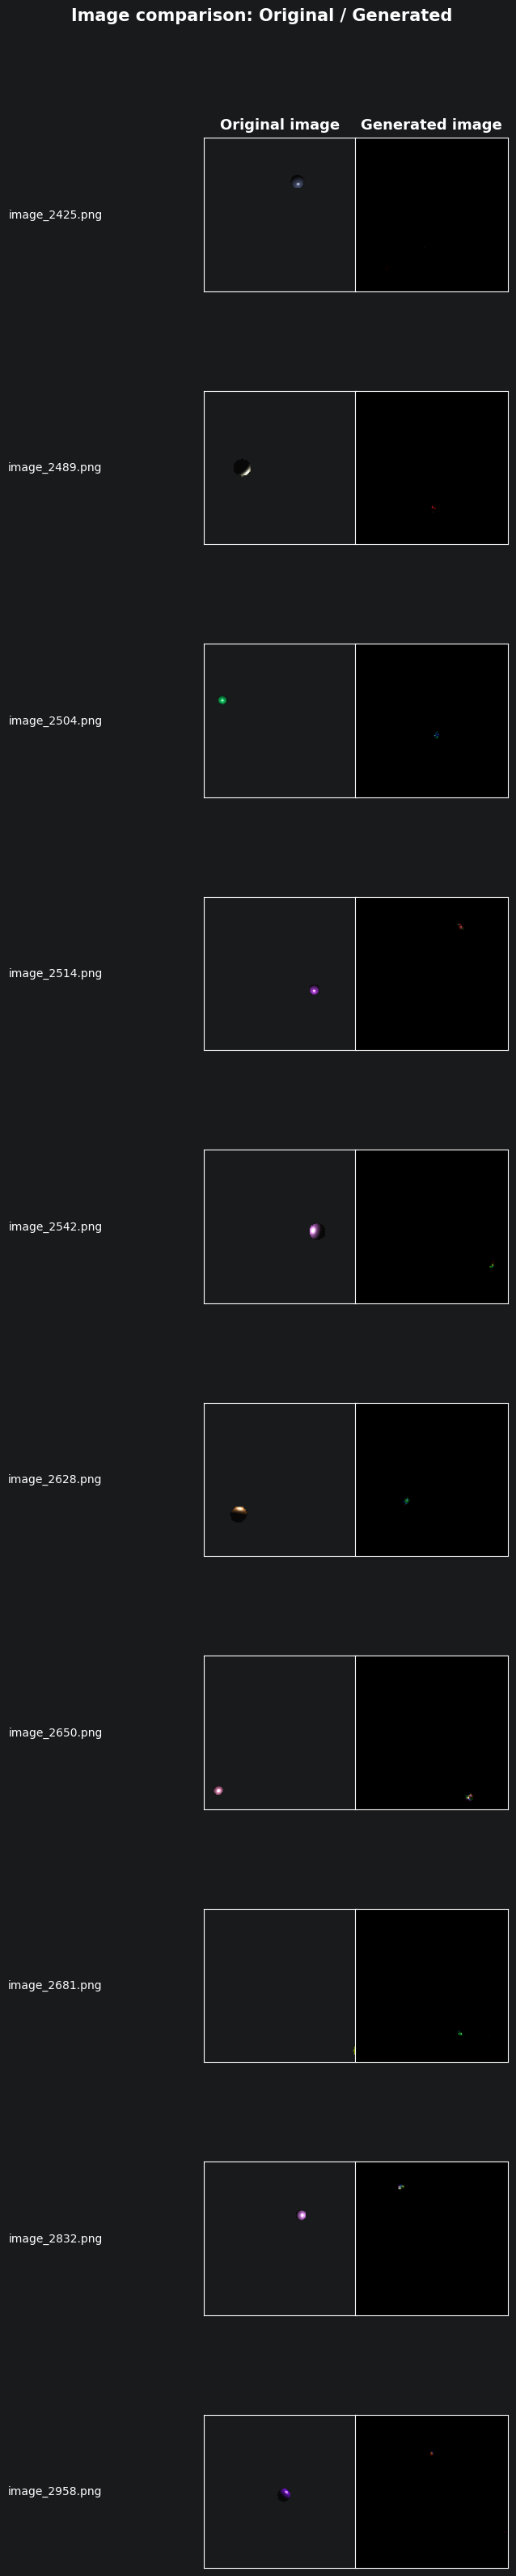

In [33]:
COLS   = ["Original image", "Generated image"]
N_COLS = 2
N_ROWS = len(chosen)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 3.2, N_ROWS * 3.2),
    squeeze=False,
)

for row_idx, gen_img_path in enumerate(chosen):
    base = gen_img_path.name
    og_img_path = IMAGES_DIR / base

    for col_idx, (img_path, col_label) in enumerate(
        zip([og_img_path, gen_img_path], COLS)
    ):
        ax = axes[row_idx][col_idx]

        if img_path.exists():
            ax.imshow(np.array(Image.open(img_path)))
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center", transform=ax.transAxes, color="red", fontsize=10)
            ax.set_facecolor("#1a1a1a")

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(col_label, fontsize=13, fontweight="bold", pad=8)

        if col_idx == 0:
            img_name = base

            ax.set_ylabel(
                f"{img_name}",
                fontsize=10, rotation=0,
                labelpad=90, va="center", ha="right",
            )

fig.suptitle(
    "Image comparison: Original / Generated",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(CURRENT_RUN_DIRECTORY / "image_comparison")
plt.show()
plt.close()

# Download the results

In [36]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)

    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)

        return

    display(FileLink(f'{download_file_name}.zip'))

In [37]:
if not LOCAL:
    download_file(CURRENT_RUN_DIRECTORY, f"SIGK_p3_{CURRENT_RUN_DIRECTORY.name}")

/kaggle/working/SIGK_p3_2026-04-27_21-00-49.zip